In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import plotly.figure_factory as ff
from plotly.subplots import make_subplots
from plotly.offline import plot, iplot, init_notebook_mode
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from scipy.cluster import hierarchy
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN


In [ ]:
cust = pd.read_csv('/content/Mall_Customers.csv', sep=',')
cust.rename(columns={"Annual Income (k$)": "Annual Income", "Spending Score (1-100)": "Spending Score"}, inplace=True)
print("There are {:,} observations and {} columns in the data set.".format(cust.shape[0], cust.shape[1]))
print("There are {} missing values in the data.".format(cust.isna().sum().sum()))
cust.head()

There are 200 observations and 5 columns in the data set.
There are 0 missing values in the data.


,CustomerID,Gender,Age,Annual Income,Spending Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


Number of clusters: 1


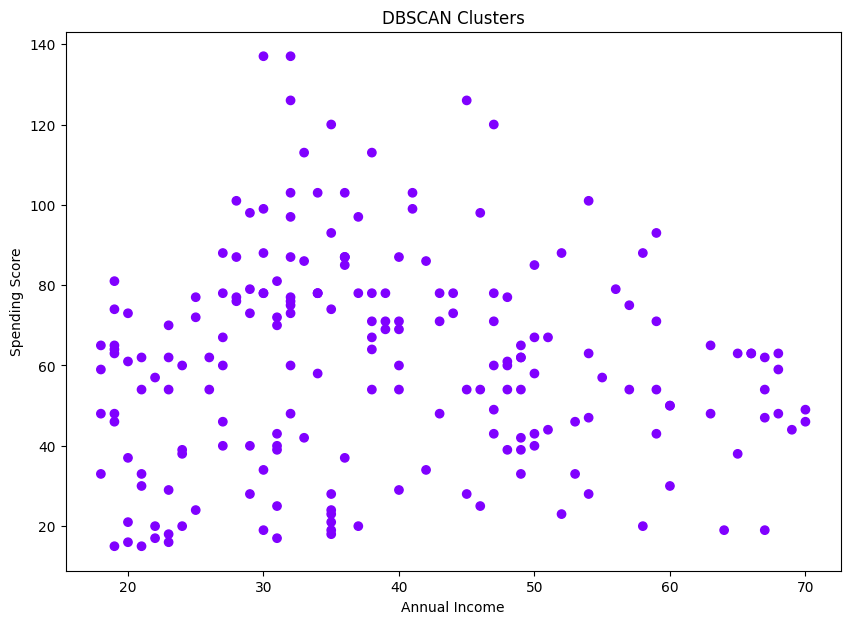

In [ ]:
# prompt: DB Scan clustering

from sklearn.cluster import DBSCAN

# Define the clustering model
dbscan = DBSCAN(eps=0.5, min_samples=10)

# Fit the model to the data
labels = dbscan.fit_predict(cust.iloc[:, 2:])

# Add the cluster labels to the DataFrame
cust['Cluster'] = labels

# Print the number of clusters
print('Number of clusters: {}'.format(len(np.unique(labels))))

# Visualize the clusters
plt.figure(figsize=(10, 7))
plt.scatter(cust.iloc[:, 2], cust.iloc[:, 3], c=labels, cmap='rainbow')
plt.title('DBSCAN Clusters')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.show()
